# 04c. Model Evaluation


## 1. Environment Setup
Load the saved models and test datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import classification_report, confusion_matrix

agg_model = pd.read_parquet('data/processed/modeling_ready.parquet')
main_model = joblib.load('models/random_forest_surge.joblib')
meta = joblib.load('models/model_metadata.joblib')

feature_cols = meta['feature_cols']
numeric_cols = meta.get('numeric_cols', [])
categorical_cols = meta.get('categorical_cols', [])
main_threshold = meta['main_threshold']
surge_threshold = meta['surge_threshold']

# Re-generate test split for evaluation
available_years = sorted(agg_model['year'].unique())
if 2026 in available_years:
    test_mask = agg_model['year'] >= 2026
elif 2025 in available_years:
    test_mask = agg_model['year'] == 2025
else:
    cutoff = np.quantile(agg_model['time_bin'].view('int64'), 0.8)
    test_mask = agg_model['time_bin'].view('int64') >= cutoff

X_test = agg_model.loc[test_mask, feature_cols]
y_test = agg_model.loc[test_mask, 'is_surge']
main_test_prob = main_model.predict_proba(X_test)[:, 1]

print('Data and models loaded. Test split reconstructed.')


Data and models loaded. Test split reconstructed.


## 2. Performance Metrics
Generate classification reports and confusion matrices for the test split.

Random forest classification report on test split:
              precision    recall  f1-score   support

           0      0.922     0.952     0.937      8523
           1      0.821     0.734     0.775      2563

    accuracy                          0.902     11086
   macro avg      0.872     0.843     0.856     11086
weighted avg      0.899     0.902     0.900     11086



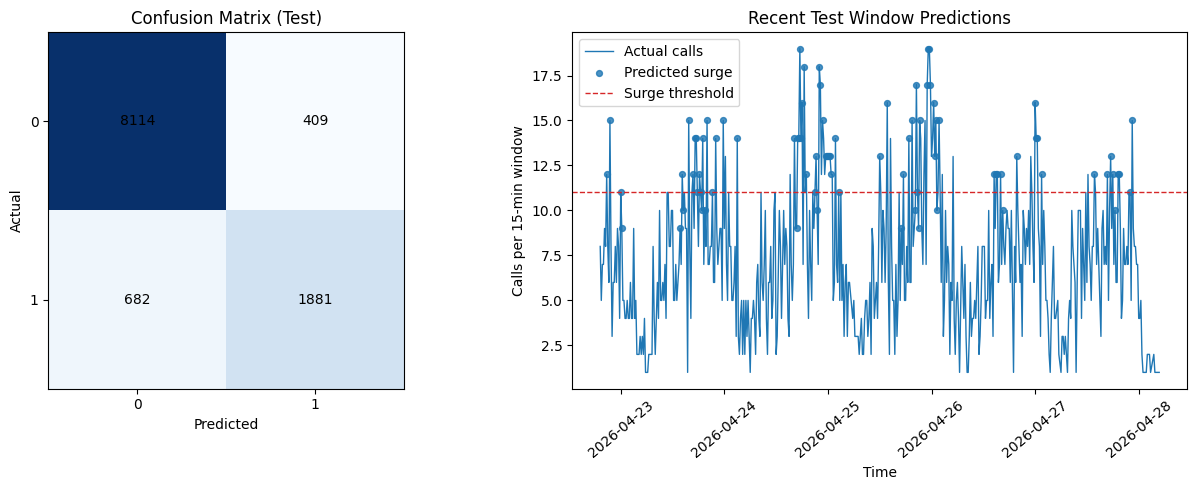

In [2]:
main_test_pred = (main_test_prob >= main_threshold).astype(int)
cm = confusion_matrix(y_test, main_test_pred)
print("Random forest classification report on test split:")
print(classification_report(y_test, main_test_pred, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, int(cm[i, j]), ha="center", va="center", color="black")

test_frame = agg_model.loc[test_mask, ["time_bin", "total_calls", "is_surge"]].copy()
test_frame["surge_prob"] = main_test_prob
test_frame["pred_surge"] = main_test_pred
plot_points = test_frame.tail(500).copy()

axes[1].plot(
    plot_points["time_bin"],
    plot_points["total_calls"],
    label="Actual calls",
    linewidth=1.0,
)
axes[1].scatter(
    plot_points.loc[plot_points["pred_surge"] == 1, "time_bin"],
    plot_points.loc[plot_points["pred_surge"] == 1, "total_calls"],
    s=18,
    label="Predicted surge",
    alpha=0.8,
)
axes[1].axhline(
    surge_threshold,
    color="tab:red",
    linestyle="--",
    linewidth=1.0,
    label="Surge threshold",
)
axes[1].set_title("Recent Test Window Predictions")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Calls per 15-min window")
axes[1].tick_params(axis="x", rotation=40)
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

## 3. Feature Importance
Analyze and visualize the primary drivers of the surge prediction model.

,feature,importance
0,unique_call_types,0.633261
1,rolling_calls_mean_4,0.090612
2,rolling_calls_mean_12,0.069556
3,hour,0.065291
4,lag_calls_1,0.030244
5,lag_calls_2,0.028436
6,lag_calls_4,0.017534
7,rolling_calls_std_12,0.012512
8,lag_calls_8,0.012434
9,lag_calls_12,0.006034


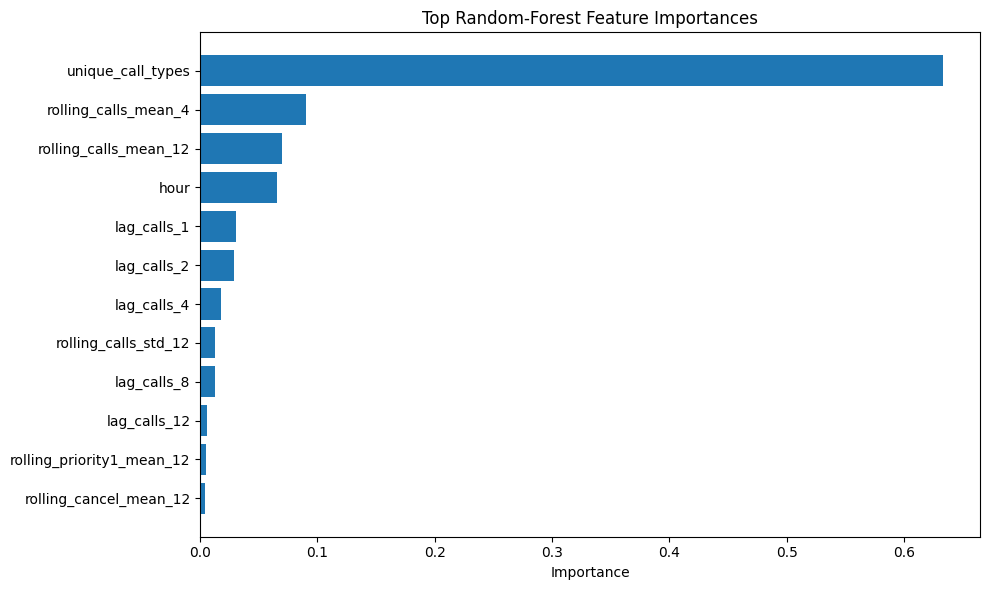

In [3]:
rf = main_model.named_steps["model"]
ohe = main_model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(["day_of_week"]))
all_feature_names = numeric_cols + cat_feature_names

importance = (
    pd.DataFrame({"feature": all_feature_names, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance.head(15))

plt.figure(figsize=(10, 6))
top_imp = importance.head(12).iloc[::-1]
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top Random-Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()